In [1]:
import pandas as pd
import src.paths

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


def profile_text_length(df, text_column, dataset_name="Dataset", pdf_filename=None):
    """
    Calculates word counts, plots the distribution, extracts percentiles,
    and optionally saves the plot as a vectorized PDF for LaTeX.
    """
    word_counts = df[text_column].fillna(
        "").apply(lambda x: len(str(x).split()))

    print(f"--- Text Length EDA: {dataset_name} ({text_column}) ---")
    print(f"Total Documents: {len(word_counts)}")
    print(f"Mean Word Count:   {word_counts.mean():.2f}")
    print(f"Std Dev:           {word_counts.std():.2f}")

    q2 = word_counts.quantile(0.50)
    q3 = word_counts.quantile(0.75)
    print(f"\n[Verbosity Thresholds]")
    print(f"Q(0.50) [Start of Q3]: {q2}")
    print(f"Q(0.75) [Start of Q4]: {q3}\n")

    plt.figure(figsize=(8, 4))
    sns.histplot(word_counts, bins=50, kde=True, color='steelblue')
    plt.axvline(q2, color='orange', linestyle='--', label=f'Q2 (50%): {q2}')
    plt.axvline(q3, color='red', linestyle='--', label=f'Q3 (75%): {q3}')
    plt.title(f'Word Count Distribution: {dataset_name}')
    plt.xlabel('Word Count')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()

    if pdf_filename:
        # Save as PDF before calling plt.show()
        plt.savefig(f"{pdf_filename}.pdf", format='pdf', bbox_inches='tight')
        print(f"Plot saved to {pdf_filename}.pdf")

    plt.show()
    return word_counts


def profile_target_variable(df, target_col, is_categorical=False, dataset_name="Dataset", pdf_filename=None):
    """
    Profiles the target variable and optionally saves the plot as a vectorized PDF.
    """
    target_data = df[target_col].dropna()

    print(f"--- Target Variable EDA: {dataset_name} ({target_col}) ---")

    plt.figure(figsize=(8, 4))

    if is_categorical:
        counts = target_data.value_counts().sort_index()
        percentages = target_data.value_counts(
            normalize=True).sort_index() * 100

        # Create a clean dataframe for export
        summary_df = pd.DataFrame({
            'Rating': counts.index,
            'Count (N)': counts.values,
            'Percentage (\\%)': percentages.values.round(2)
        })

        print("Class Distribution:")
        print(summary_df.to_string(index=False))

        # Generate the LaTeX code automatically
        print("\n--- LaTeX Table Output ---")
        latex_code = summary_df.to_latex(
            index=False,
            caption=f"Distribution of Human Ratings for {dataset_name}",
            label="tab:human_ratings_dist",
            column_format="lcc"  # Left align first col, center the numbers
        )
        print(latex_code)

        # We skip plotting entirely for the categorical data
        return summary_df
    else:
        mean_val = target_data.mean()
        var_val = target_data.var()

        print(f"Mean:              {mean_val:.2f}")
        print(f"Variance:          {var_val:.2f}")
        print(f"Dispersion Index:  {var_val / mean_val:.2f}")

        sns.histplot(target_data, bins=max(
            30, int(target_data.nunique()/2)), kde=False, color='seagreen')
        plt.title(f'Target Distribution (Count): {dataset_name}')
        plt.xlabel('Count Value')
        plt.ylabel('Frequency')

    plt.tight_layout()

    if pdf_filename:
        # Save as PDF before calling plt.show()
        plt.savefig(f"{pdf_filename}.pdf", format='pdf', bbox_inches='tight')
        print(f"Plot saved to {pdf_filename}.pdf")

    plt.show()

# EDA

## FeedbackQA

In [3]:
qa = pd.read_parquet(src.paths.PROCESSED_DATA_DIR /
                     "MCGILL_FEEDBACKQA_V2.parquet")
qa['QA_text'] = qa['question'] + "\n" + qa["answer"]

qa['word_counts'] = qa['QA_text'].fillna(
    "").apply(lambda x: len(str(x).split()))

In [4]:
# profile_text_length(
#     qa, "QA_text", pdf_filename='plots/feedbackqa_word_count.pdf')

In [5]:
df_long = pd.melt(
    qa,
    id_vars='input_id',
    value_vars=['score_1', 'score_2'],
    value_name='human_rating'
)
# profile_target_variable(df_long, "human_rating")


# 1. Map the integers back to their actual semantic labels
label_mapping = {1: '1 - Bad', 2: '2 - Could be improved',
                 3: '3 - Good', 4: '4 - Excellent'}
df_long['rating_label'] = df_long['human_rating'].map(label_mapping)

# 2. Run the profile function WITH is_categorical=True
profile_target_variable(
    df=df_long,
    target_col='rating_label',
    is_categorical=True,       # <--- This is the crucial fix
    dataset_name='FeedbackQA',
    # pdf_filename='feedbackqa_human_distribution'
)

--- Target Variable EDA: FeedbackQA (rating_label) ---
Class Distribution:
               Rating  Count (N)  Percentage (\%)
              1 - Bad       6086            33.57
2 - Could be improved       3120            17.21
             3 - Good       3188            17.58
        4 - Excellent       5736            31.64

--- LaTeX Table Output ---
\begin{table}
\caption{Distribution of Human Ratings for FeedbackQA}
\label{tab:human_ratings_dist}
\begin{tabular}{lcc}
\toprule
Rating & Count (N) & Percentage (\%) \\
\midrule
1 - Bad & 6086 & 33.570000 \\
2 - Could be improved & 3120 & 17.210000 \\
3 - Good & 3188 & 17.580000 \\
4 - Excellent & 5736 & 31.640000 \\
\bottomrule
\end{tabular}
\end{table}



,Rating,Count (N),Percentage (\%)
0,1 - Bad,6086,33.57
1,2 - Could be improved,3120,17.21
2,3 - Good,3188,17.58
3,4 - Excellent,5736,31.64


<Figure size 800x400 with 0 Axes>

In [39]:
for i in range(10):
    print("Question & Answer:")
    print(qa[(qa['score_1'] + qa['score_2']) == 2]['QA_text'].iloc[i])
    print("Feedback:")
    print(qa[(qa['score_1'] + qa['score_2']) == 2]['explanation_2'].iloc[i])

Question & Answer:
Do immigration detention centers have proper PPE?
If clinically indicated detainees will be tested in line with advice from
health professionals and will be isolated pending test results.
Our Detention Health service provider has conducted public health awareness
activities and posted information at sites on hand hygiene and other
preventive measures detainees can take.
Feedback:
The question is about the availability of PPE at detention facilities not testing and posting other info.
Question & Answer:
Do immigration detention centers have proper PPE?
It has been observed that most religious groups are self-electing to cease
visits to detention facilities as they adhere to the measures being
implemented within the community.
Each detention facility has a Religious Liaison Officer (RLO) who is working
with a number of religious groups to ensure alternate methods for religious
observance. In some cases, pre-recorded services are being made available
where a religious g

## Barter Deals

In [6]:
deals = pd.read_parquet(
    src.paths.PROCESSED_DATA_DIR / "BARTER_DEALS_MODEL_READY.parquet")

In [7]:
deals['full_text'] = deals['deal_title'] + \
    deals['deal_text'] + deals['creators_requirement']

--- Text Length EDA: Dataset (creators_requirement) ---
Total Documents: 3139
Mean Word Count:   74.92
Std Dev:           79.55

[Verbosity Thresholds]
Q(0.50) [Start of Q3]: 53.0
Q(0.75) [Start of Q4]: 98.0

Plot saved to ../latex_thesis/figures/barter_word_count.pdf.pdf


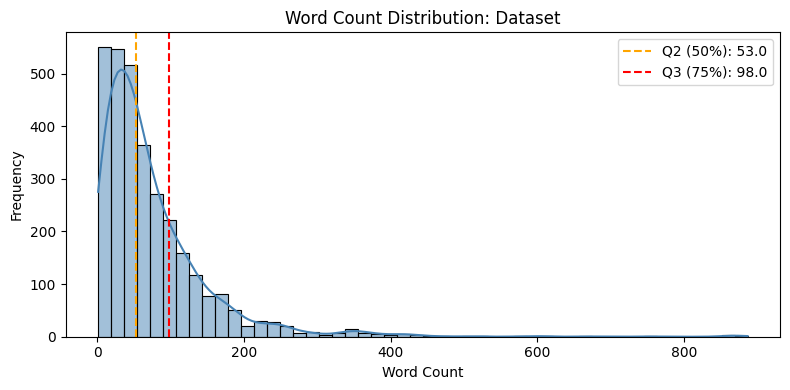

3084     22
3085     33
3086     50
3087     20
3088     42
       ... 
6820     44
6821     64
6822    114
6823     47
6824     40
Name: creators_requirement, Length: 3139, dtype: int64

In [8]:
profile_text_length(
    deals, "creators_requirement", pdf_filename='../latex_thesis/figures/barter_word_count.pdf')

--- Text Length EDA: Dataset (deal_text) ---
Total Documents: 3139
Mean Word Count:   81.89
Std Dev:           72.13

[Verbosity Thresholds]
Q(0.50) [Start of Q3]: 64.0
Q(0.75) [Start of Q4]: 104.0

Plot saved to ../latex_thesis/figures/barter_word_count.pdf.pdf


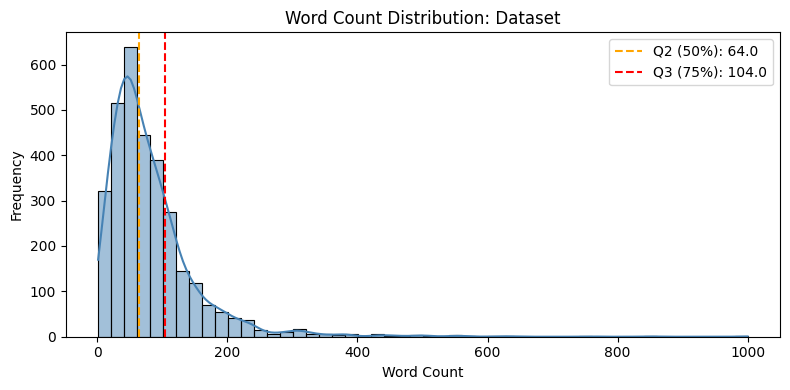

3084     25
3085     29
3086     39
3087     39
3088     88
       ... 
6820     65
6821    127
6822     51
6823    135
6824     92
Name: deal_text, Length: 3139, dtype: int64

In [9]:
profile_text_length(
    deals, "deal_text", pdf_filename='../latex_thesis/figures/barter_word_count.pdf')

--- Text Length EDA: Dataset (full_text) ---
Total Documents: 3139
Mean Word Count:   160.76
Std Dev:           117.18

[Verbosity Thresholds]
Q(0.50) [Start of Q3]: 135.0
Q(0.75) [Start of Q4]: 204.0

Plot saved to ../latex_thesis/figures/barter_word_count.pdf.pdf


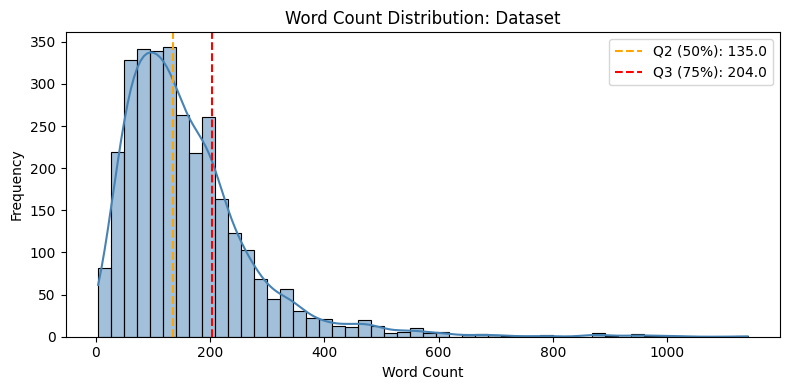

3084     51
3085     66
3086     94
3087     65
3088    136
       ... 
6820    114
6821    198
6822    168
6823    187
6824    139
Name: full_text, Length: 3139, dtype: int64

In [10]:
profile_text_length(
    deals, "full_text", pdf_filename='../latex_thesis/figures/barter_word_count.pdf')

--- Text Length EDA: Dataset (full_text) ---
Total Documents: 3139
Mean Word Count:   160.76
Std Dev:           117.18

[Verbosity Thresholds]
Q(0.50) [Start of Q3]: 135.0
Q(0.75) [Start of Q4]: 204.0



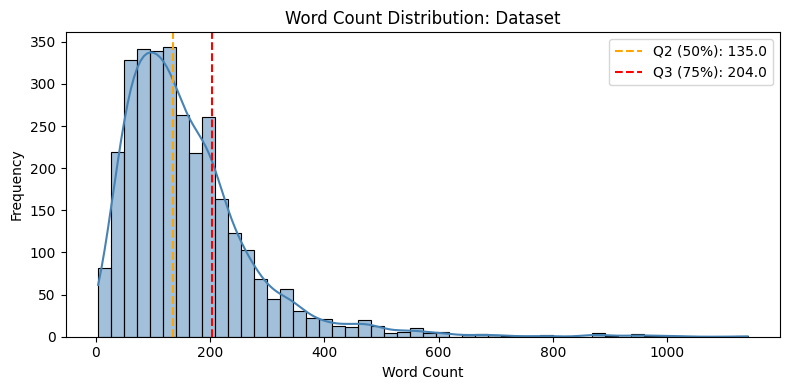

3084     51
3085     66
3086     94
3087     65
3088    136
       ... 
6820    114
6821    198
6822    168
6823    187
6824    139
Name: full_text, Length: 3139, dtype: int64

In [11]:
profile_text_length(deals, "full_text")

--- Target Variable EDA: Dataset (apps_after_7_days) ---
Mean:              15.80
Variance:          478.70
Dispersion Index:  30.29


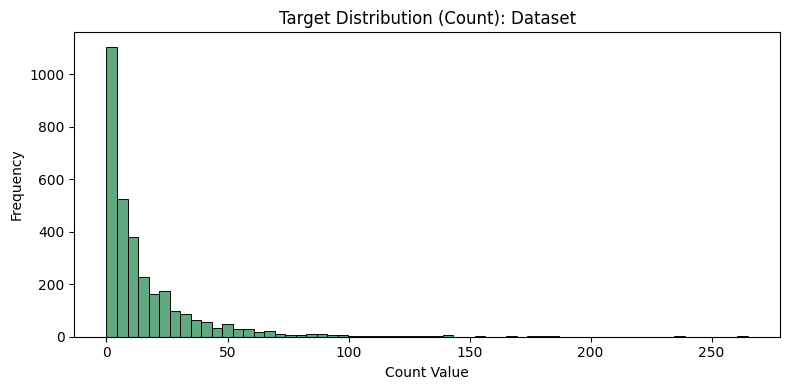

In [12]:
profile_target_variable(deals, 'apps_after_7_days')